In [11]:
%load_ext autoreload
%autoreload 2

import anndata as ad
import datalair
import icir
from pathlib import Path
import scanpy as sc
import pandas as pd
from scipy import stats

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# deconv functions

In [2]:
import numpy as np
import numpy.typing as npt
from numpy.random import Generator

def deconvolution(bulk: np.array, reference: np.array, n: int, eps: float) -> np.array:
    """
    Performs a deconvolution process on the provided bulk dataset using a reference matrix.

    This function implements an iterative computational deconvolution to infer proportions
    or contributions of the reference dataset to the bulk dataset.

    Args:
        bulk (np.array): A 1-dimensional array representing the bulk dataset, where
            each element captures an aggregate data point.
        reference (np.array): A 2-dimensional array where each row represents a
            reference signature, and columns indicate features. The shape of this
            array should be (c, g), where 'c' is the number of reference elements
            and 'g' is the number of features/signatures.
        n (int): The number of iterations to perform for the deconvolution process.
        eps (float): A small epsilon value added to avoid division by zero during the
            normalization process.

    Returns:
        np.array: A 2-dimensional array representing the result of the deconvolution
        process. The output matrix has the same shape as the reference matrix, where
        each entry indicates the inferred proportion of contribution.
    """
    c, g = reference.shape

    # Initialize expression matrix
    B = np.ones(shape=(c, g)) / np.repeat(c * g, c * g).reshape((c, g))

    # Iteration scheme
    for i in range(n):
        print()
        B = reference * np.repeat(B.sum(axis=1), g).reshape((c, g))
        B = B / (np.repeat(B.sum(axis=0), c).reshape((g, c)).T + eps)
        B = B * np.repeat(bulk, c).reshape((g, c)).T

    return B

def insta_prism(
    bulk: np.ndarray,             # shape (1, G) or (G,)
    reference: np.ndarray,        # shape (S, G): S cell types × G genes
    n_iter: int = 1000
) -> np.array:
    """
    Performs deconvolution of gene expression data to estimate cell proportions,
    cell state gene expression, and probability matrix.

    This function estimates the contribution of each cell type to the observed
    gene expression data (bulk), using an iterative procedure. It updates the
    probability matrix, cell state gene expression, and cell fractions until
    a specified number of iterations is reached.

    Args:
        bulk: np.ndarray
            Gene expression data for a bulk sample. Can be a 1D array with
            shape (G,) or a 2D array with shape (1, G), where G is the number
            of genes.
        reference: np.ndarray
            Reference gene expression profiles for S cell types. Expected as a
            2D array with shape (S, G), where S is the number of cell types
            and G is the number of genes.
        n_iter: int
            The number of iterations for the iterative estimation process.

    Returns:
        np.ndarray
            Tuple containing three arrays:
            - probability_matrix: Estimates for the probability matrix of dimensions
              reflecting the relationships among genes and cell types.
            - cell_state_gene_expression: Gene expression matrix for each cell state.
            - cell_fractions: Estimated proportions of cell types in the bulk sample.
    """
    bulk = _validate_bulk(bulk)
    reference = _validate_reference(reference).T   # (G, S)

    cell_fractions, cell_state_gene_expression, probability_matrix = _initialize_deconvolution_arrays(reference)
    for _ in range(n_iter):
        _update_probability_matrix_inplace(reference, cell_fractions, probability_matrix)
        _update_cell_state_gene_expression_by_fixpoint_inplace(cell_state_gene_expression, bulk, probability_matrix)
        _update_cell_fractions_estimate_by_fixpoint_inplace(cell_fractions, cell_state_gene_expression)
    return probability_matrix, cell_state_gene_expression, cell_fractions


def _update_cell_state_gene_expression_by_fixpoint_inplace(
        cell_state_gene_expression: np.ndarray,
        bulk: np.ndarray,
        probability_matrix: np.ndarray
) -> None:
    """
    Updates cell state gene expression matrix inplace by multiplying the bulk data
    with the probability matrix.

    This function performs element-wise multiplication of the provided bulk dataset
    with the probability matrix, broadcasting as required, and stores the result
    directly into the provided cell_state_gene_expression matrix. The input is
    modified in-place to improve performance and reduce memory overhead.

    Args:
        cell_state_gene_expression: Matrix that stores the final updated cell state
            gene expression values. The matrix is updated in-place.
        bulk: Array containing bulk data which will be used for updating the
            cell state gene expression matrix.
        probability_matrix: Matrix containing probability values for corresponding
            elements that will be used during the update process.

    """
    np.multiply(bulk[:, np.newaxis], probability_matrix, out=cell_state_gene_expression)


def _update_cell_fractions_estimate_by_fixpoint_inplace(cell_fractions: np.ndarray,
                                                        cell_state_gene_expression: np.ndarray) -> None:
    """
    Updates the cell fractions estimate in place by normalizing the sum of gene expression
    values across cell states. This function modifies the `cell_fractions` array directly based
    on calculations derived from `cell_state_gene_expression`.

    Args:
        cell_fractions: A NumPy array that will be updated in place to represent the normalized
            proportions of cell fractions. The values in this array are overwritten based on
            calculations from `cell_state_gene_expression`.
        cell_state_gene_expression: A NumPy 2D array containing gene expression values where
            rows represent genes and columns correspond to different cell states. The function
            calculates the sum across rows for each cell state and uses these values to update
            `cell_fractions`.
    """
    cell_fractions[:] = cell_state_gene_expression.sum(axis=0)
    cell_fractions /= cell_fractions.sum()


def _update_probability_matrix_inplace(reference: np.array, theta: np.array, probability_matrix: np.array) -> None:
    """
    Updates the probability matrix in-place based on the provided reference and theta arrays.

    This function multiplies the `reference` and `theta` arrays element-wise and updates the
    `probability_matrix` in place. Afterward, the updated `probability_matrix` rows are normalized
    so that the sum of their elements equals 1. It is assumed that no rows in the resulting
    probability matrix will have a sum of zero, thereby avoiding division by zero errors.

    Args:
        reference (np.array): A 2D array representing the reference data.
        theta (np.array): A 2D array with the same shape as `reference`.
        probability_matrix (np.array): A 2D array that will be updated in-place.
    """
    probability_matrix[:] = reference * theta  # (G, S)
    probability_matrix /= probability_matrix.sum(axis=1, keepdims=True)  # no divide-by-zero assumed


def bayes_prism(
    bulk: np.ndarray,             # shape (1, G) or (G,)
    reference: np.ndarray,        # shape (S, G): S cell types × G genes
    n_iter: int = 1000,
    alpha: float = 1e-4,
    rng: Generator = np.random.default_rng(0),
):
    """
    Performs Bayesian deconvolution of bulk gene expression data using a reference
    matrix of cell-type-specific gene expression.

    This function applies an iterative approach to estimate two key outputs:
    cell state gene expression and cell type fractions. Using Bayesian updates,
    it refines these estimates based on given input data.

    Args:
        bulk (np.ndarray): A 1-dimensional array of bulk gene expression data with
            shape `(1, G)` or `(G,)`, where `G` is the number of genes.
        reference (np.ndarray): A 2-dimensional reference matrix with shape `(S, G)`,
            where `S` is the number of cell types, and `G` is the number of genes.
        n_iter (int): Number of iterations for the Bayesian updates. Defaults to 1000.
        alpha (float): Dirichlet prior parameter for cell fractions. Defaults to 1e-4.
        rng (Generator): A NumPy random number generator instance for control over
            the random sampling process. Defaults to a generator initialized with
            `np.random.default_rng(0)`.

    Returns:
        Tuple[np.ndarray, np.ndarray]: A tuple containing:
            - cell_state_gene_expression (np.ndarray): A matrix representing the
              updated cell state gene expression.
            - cell_fractions (np.ndarray): An array representing the estimated
              proportions of each cell type.
    """
    bulk = _validate_bulk(bulk)
    reference = _validate_reference(reference).T   # (G, S)

    cell_fractions, cell_state_gene_expression, probability_matrix = _initialize_deconvolution_arrays(reference)
    for _ in range(n_iter):
        _update_probability_matrix_inplace(reference, cell_fractions, probability_matrix)
        _update_cell_state_gene_expression_by_sampling_inplace(cell_state_gene_expression, bulk, probability_matrix, rng)
        _update_cell_fractions_estimate_by_sampling_inplace(cell_fractions, cell_state_gene_expression, alpha, rng)
    return cell_state_gene_expression, cell_fractions


def _validate_reference(reference: np.ndarray) -> np.ndarray:
    """
    Validates the provided reference data by ensuring it is a numeric 2D array.

    The function converts the input reference data into a NumPy array with
    a float64 data type and checks that it is a two-dimensional array. If the
    validation fails, an assertion error is raised.

    Args:
        reference: The input data array to validate. Must be convertible to a
            NumPy array with numeric data type and must have two dimensions.

    Returns:
        A NumPy array with dtype float64 representing the validated reference data.
    """
    reference = np.asarray(reference, dtype=np.float64)  # Ensure numeric dtype
    assert reference.ndim == 2, "reference must be a 2D array"
    return reference


def _initialize_deconvolution_arrays(reference: np.ndarray) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Initializes and returns arrays used for the deconvolution process.

    This function creates and initializes three arrays necessary for the
    deconvolution process. The cell fractions array is initialized with
    equal values summing to 1, while the probability matrix and
    cell state gene expression matrix are pre-allocated with appropriate
    dimensions based on the reference matrix.

    Args:
        reference (numpy.ndarray): A 2D array representing the reference data,
            where rows correspond to genes, and columns correspond to cells.

    Returns:
        tuple: A tuple containing:
            - numpy.ndarray: A 1D array representing cell fractions, initialized
              such that each cell has an equal fraction.
            - numpy.ndarray: A 2D array for cell state gene expression, pre-allocated
              based on the dimensions of the reference matrix.
            - numpy.ndarray: A 2D array for the probability matrix, pre-allocated
              based on the reference dimensions.
    """
    gene_number, cell_number = reference.shape  # (G, S)
    cell_fractions = np.full(cell_number, 1.0 / cell_number)
    probability_matrix = np.empty((gene_number, cell_number), dtype=np.float64)
    cell_state_gene_expression = np.empty((gene_number, cell_number), dtype=np.float64)
    return cell_fractions, cell_state_gene_expression, probability_matrix


def _update_cell_fractions_estimate_by_sampling_inplace(
        cell_fractions: np.array,
        cell_state_gene_expression: np.array, alpha: float,
        rng: Generator
) -> None:
    """
    Updates the cell fractions estimate in place by sampling from a Dirichlet distribution.x

    This function modifies the input cell fractions directly, updating its values based on a
    Dirichlet distribution. The parameters of the distribution are derived from the sum of
    the cell state gene expression and the provided alpha value.

    Args:
        cell_fractions: numpy array, modified in place to reflect updated cell fraction
            estimates.
         cell_state_gene_expression: numpy array representing gene expression levels for
            different cell states.
        alpha: float, the concentration parameter added to the summed gene expression to
            form the parameters of the Dirichlet distribution.
        rng: numpy.random.Generator, used to sample from the Dirichlet distribution.
    """
    cell_fractions[:] = rng.dirichlet(cell_state_gene_expression.sum(axis=0) + alpha)


def _update_cell_state_gene_expression_by_sampling_inplace(
        cell_state_gene_expression: np.ndarray,
        bulk: np.ndarray,
        probability_matrix: np.ndarray,
        rng: Generator
) -> None:
    """
    Updates the `cell_state_gene_expression` matrix by sampling using a multinomial distribution.

    This function modifies the `cell_state_gene_expression` in place based on the values of the
    `bulk` vector and the `probability_matrix`. The sampling is performed row-wise in the
    `cell_state_gene_expression` matrix using the multinomial distribution with parameters
    provided in `bulk` and `probability_matrix` for each row. The randomness of the sampling
    process is managed by the provided random number generator `rng`.

    Args:
        cell_state_gene_expression (np.ndarray): A 2D array representing the cell state gene
            expression to be updated in place.
        bulk (np.ndarray): A 1D array containing the total values for each gene to use in the
            multinomial sampling process.
        probability_matrix (np.ndarray): A 2D array representing the probability matrix
            used for the multinomial sampling, where each row corresponds to a gene, and the
            columns correspond to probabilities for each cell state.
        rng (np.random.Generator): A random number generator instance used for multinomial
            sampling to ensure reproducibility across runs.
    """
    for g in range(cell_state_gene_expression.shape[0]):
        cell_state_gene_expression[g, :] = rng.multinomial(bulk[g], probability_matrix[g, :])


def _validate_bulk(bulk):
    """
    Validates the input bulk data for correct dimensionality and format.

    This function ensures that the input 'bulk' is either a 1D array or a 2D array
    with a single sample. If these conditions are not met, it raises an assertion
    error. The input is converted to a NumPy array and conditioned for further
    processing.

    Args:
        bulk: Input array-like object representing bulk data. It can be of any
            shape and will be validated to ensure it is either a 1D array or
            a 2D array with one sample.

    Returns:
        A 1D NumPy array corresponding to the validated bulk data.

    Raises:
        AssertionError: If the input 'bulk' has dimensions other than 1D, or 2D
            with a single sample.
    """
    bulk = np.asarray(bulk)
    if bulk.ndim == 2:
        assert bulk.shape[0] == 1, "bulk must have a single sample"
        X = bulk.ravel()  # shape (G,)
    elif bulk.ndim == 1:
        X = bulk
    else:
        raise AssertionError("bulk must be 1D or 2D with one sample")
    return X


def _normalize_rows_to_stochastic(x: npt.NDArray[np.int64 | np.float64]):
    """
    Normalizes the rows of a 2D array to make them stochastic.

    This function ensures that the rows of the input 2D array sum to 1, effectively
    turning the array into a row-stochastic matrix. Each row is divided by the sum
    of its elements.

    Args:
        x: A 2D NumPy array of integers or floats. The array must have two dimensions
           (ndim=2).

    Returns:
        A 2D NumPy array where each row has been normalized such that the sum of
        elements in each row equals 1. The output array will have the same shape as
        the input array.

    Raises:
        AssertionError: If the input array is not a 2D array (ndim != 2).
    """
    assert x.ndim == 2, "Input must be a 2D array"
    return x / x.sum(axis=1).reshape((x.shape[0], 1))


def _calculate_fractions(x: npt.NDArray[np.int64 | np.float64]):
    """
    Calculates fractions from the input array by summing along the rows and normalizing the result.

    This function takes a NumPy array, computes the sum along its rows, and normalizes these sums
    to create a fraction representation. The output is a 1D array of fractions representing the relative
    contributions of row-wise sums to the overall sum.

    Args:
        x: A NumPy array containing integer or float values. The input array should have at least two dimensions.

    Returns:
        A 1D NumPy array of float values representing the normalized fractions derived from the input array.
    """
    theta = x.sum(axis=1)
    theta = theta / theta.sum()
    return theta

# deconvolutions

In [3]:
data_dir = Path("/home/halu/code/tme_analysis/data/").resolve()
lair = datalair.Lair("/storage/halu/lair")
lair.assert_ok_satus()
ds = icir.datasets.ImmuneCheckpointTherapyResponseProcessedGeneNormalizedClinicalDataNormalized()
gide = ad.read_h5ad(lair.get_dataset_filepaths(ds)["Gide.h5ad"])

/usr/lib/python3.14/functools.py:982: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


In [9]:
for name, filepath in lair.get_dataset_filepaths(ds).items():
    print(name)
    if not name == "Gide.h5ad":
        continue
    reference = ad.read_h5ad(data_dir.joinpath("references/reference_32.h5ad"))
    adata = ad.read_h5ad(filepath)
    print(adata)
    common_genes = sorted(list(set(reference.var.index).intersection(set(adata.var.index))))
    adata = adata[:, common_genes].copy()
    reference = reference[:, common_genes].copy()
    dc = []
    for i in range(0, adata.shape[0]):
        if i%10==0:
            print(i)
        result = insta_prism(adata.X[i, :].copy(), reference.X.copy(), n_iter=100)
        dc.append(result)
    fractions = np.array([res[2] for res in dc])
    log_fractions = np.log(fractions)
    log_fractions = pd.DataFrame(log_fractions, index=adata.obs_names, columns=["cell_type_{:03d}".format(i) for i in range(reference.n_obs)])
    log_fractions.to_hdf(f"/home/halu/code/tme_analysis/data/log-fractions-0.125/log-fractions-{name.removesuffix(".h5ad")}.h5pd", key="log_fractions")

Chen-CTLA4.h5ad
Gide.h5ad
AnnData object with n_obs × n_vars = 89 × 19049
    obs: 'age', 'sex', 'primary_tumor', 'overall_survival', 'response', 'RECIST', 'prior_CTLA4', 'prior_PD1', 'treatment.CTLA4', 'treatment.PD1', 'treatment.PDL1', 'treatment.KIR', 'treatment.CD137', 'treatment.IDO', 'treatment.LAG-3', 'treatment.ACT', 'treatment.CYTOSTASIS', 'timing', 'sample_source', 'original.patient_id', 'original.sample_id'
    var: 'contig', 'start', 'end', 'strand', 'biotype', 'gene_name', 'EnsemblRelease.release', 'EnsemblRelease.species', 'original.id'


/usr/lib/python3.14/functools.py:982: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


0
10
20
30
40
50
60
70
80
Freeman.h5ad
Lauss.h5ad
Liu.h5ad
Prat.h5ad
Snyder.h5ad
Riaz.h5ad
VanAllen.h5ad
Rose.h5ad
Hugo.h5ad
Auslander.h5ad
Ravi.h5ad
Chen-PD1.h5ad


In [ ]:
data1 = fractions[y_numeric==0]
data2 = fractions[y_numeric==1]
t_stat, p_val = stats.ttest_ind(data1, data2, axis=0)
(p_val < 0.05/p_val.shape[0]).sum()

In [ ]:
import numpy as np
from scipy import stats
from statsmodels.stats.power import TTestIndPower

# 1. Simulate pilot data for two groups with 400 features
# Pilot data size: 10 samples per group
pilot_group1 = fractions[y_numeric==0]
pilot_group2 = fractions[y_numeric==1]

# 2. Calculate Cohen's d for each feature
# Formula: (mean1 - mean2) / pooled_std
mean1 = np.mean(pilot_group1, axis=0)
mean2 = np.mean(pilot_group2, axis=0)

var1 = np.var(pilot_group1, axis=0, ddof=1)
var2 = np.var(pilot_group2, axis=0, ddof=1)
n1, n2 = pilot_group1.shape[0], pilot_group2.shape[0]

# Pooled standard deviation
s_pooled = np.sqrt(((n1 - 1) * var1 + (n2 - 1) * var2) / (n1 + n2 - 2))
effect_sizes = np.abs(mean1 - mean2) / s_pooled

# 3. Handle multiple testing: adjust the alpha level
# Using Bonferroni correction for 400 features
alpha_adjusted = 0.05

# 4. Power Analysis Setup
power_analysis = TTestIndPower()

# Find the maximum required sample size among all features
# (or take the average effect size, depending on your focus)
required_n_list = []
for d in effect_sizes:
    if d > 0:  # Avoid division or calculation errors on 0 effect size
        n = power_analysis.solve_power(effect_size=d, power=0.80, alpha=alpha_adjusted, ratio=1.0)
        required_n_list.append(n)

print(f"Average sample size required per group (adjusted): {np.mean(required_n_list):.0f}")
print(f"Maximum sample size required per group (worst-case feature): {np.max(required_n_list):.0f}")

In [ ]:
plt.plot([(np.array(required_n_list) < i).sum() for i in range(200)])

In [ ]:
adatas = {}
for name, filepath in lair.get_dataset_filepaths(ds).items():
    reference = ad.read_h5ad(data_dir.joinpath("references/reference_32.h5ad"))
    adata = ad.read_h5ad(filepath)
    adatas[name] = adata
    print(adata)

In [ ]:
adatas

In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 1, figsize=(20, 4))
sns.heatmap(np.log(fractions+1e-6), cmap="YlGnBu", ax=ax)

ax.set_title("Cluster Composition Fractions")
ax.set_xlabel("Cell_cluster")
ax.set_ylabel("Gide Sample")
ax.set_yticklabels([])
ax.set_xticklabels([])
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

mean = fractions.mean(axis=0)
std = fractions.std(axis=0)

fig, ax = plt.subplots(1, 1, figsize=(20, 5))

ax.bar(
    x=reference.obs["leiden"].values,
    height=mean + 1e-10,
    yerr=std,              # This adds the error bars
    capsize=5,             # Adds horizontal "caps" to the error bars
    color='skyblue',
    edgecolor='black'
)

ax.set_yscale("log")
ax.set_ylim(1e-6, 1)

plt.tight_layout()
plt.show()

In [12]:
mapping = {'NR': 0, 'R': 1}
y_numeric = gide.obs.response.map(mapping).values.astype(float)
X = np.log(fractions + 1e-6).astype(float)

correlations = []
p_values = []

for i in range(X.shape[1]):
    # Drop rows where y_numeric might be NaN (if mapping didn't cover all values)
    mask = ~np.isnan(y_numeric)

    r, p = stats.pointbiserialr(y_numeric[mask], X[mask, i])
    correlations.append(r)
    p_values.append(p)

correlations = np.array(correlations)
p_values = np.array(p_values)

/home/halu/python-venv/tme_analysis/.venv/lib/python3.14/site-packages/scipy/stats/_stats_py.py:5523: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rpb, prob = pearsonr(x, y)
/home/halu/python-venv/tme_analysis/.venv/lib/python3.14/site-packages/scipy/stats/_stats_py.py:5523: NearConstantInputWarning: An input array is nearly constant; the computed correlation coefficient may be inaccurate.
  rpb, prob = pearsonr(x, y)


In [16]:
np.sort(p_values*len(p_values))

array([2.06305192e-04, 7.90392493e-04, 1.03873701e-03, 1.44483617e-03,
       1.61547475e-03, 1.62085188e-03, 2.38540240e-03, 2.45429622e-03,
       8.56579154e-03, 8.89201661e-03, 1.45257421e-02, 1.96080101e-02,
       2.78607587e-02, 1.01900527e-01, 1.52517551e-01, 1.69414250e-01,
       3.24543277e-01, 3.94791669e-01, 3.97069159e-01, 4.30483131e-01,
       4.33261980e-01, 4.35015256e-01, 4.48657212e-01, 4.77053448e-01,
       4.83724571e-01, 5.65312204e-01, 6.64285468e-01, 7.92509903e-01,
       8.03533154e-01, 1.00530987e+00, 1.03449215e+00, 1.06044643e+00,
       1.15413899e+00, 1.25425941e+00, 1.28734421e+00, 1.60035632e+00,
       1.75995084e+00, 1.77916915e+00, 2.08558718e+00, 2.28884561e+00,
       2.31233214e+00, 2.44752736e+00, 2.49589091e+00, 2.86991884e+00,
       3.24792545e+00, 3.59781120e+00, 3.90193610e+00, 4.49668608e+00,
       5.30149607e+00, 5.48889517e+00, 5.99963715e+00, 6.43694430e+00,
       7.46732017e+00, 8.08056827e+00, 8.88509112e+00, 8.91438165e+00,
      

In [ ]:
n_bootstrap = 1000
bootstrap_correlations = []

n_samples = X.shape[0]

for b in range(n_bootstrap):
    if b%100==0:
        print(b)
    boot_idx = np.random.choice(n_samples, size=n_samples, replace=True)
    X_boot = X[boot_idx]
    y_boot = y_numeric[boot_idx]

    corrs = []
    for i in range(X_boot.shape[1]):
        mask = ~np.isnan(y_boot)
        r, p = stats.spearmanr(y_boot[mask], X_boot[mask, i])
        corrs.append(r)

    bootstrap_correlations.append(corrs)

bootstrap_correlations = np.array(
    bootstrap_correlations)  # shape: (n_bootstrap, n_features)

correlations = np.nanmean(bootstrap_correlations, axis=0)
correlations_std = np.nanstd(bootstrap_correlations, axis=0)
correlations_ci_low = np.nanpercentile(bootstrap_correlations, 2.5, axis=0)
correlations_ci_high = np.nanpercentile(bootstrap_correlations, 97.5, axis=0)

sorted_idx = np.argsort(correlations)
x_pos = np.arange(len(sorted_idx))

plt.figure(figsize=(12, 5))
plt.plot(x_pos, correlations[sorted_idx], label='Mean correlation')
plt.fill_between(x_pos, correlations_ci_low[sorted_idx],
                 correlations_ci_high[sorted_idx], alpha=0.3, label='95% CI')
plt.axhline(0, color='black', linestyle='--', alpha=0.5)
plt.xlabel('Feature (sorted by correlation)')
plt.ylabel('Spearman correlation')
plt.title(f'Bootstrap distribution of correlations (n={n_bootstrap})')
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
from sklearn.linear_model import Lasso
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler

# Handle NaN mask for y_numeric
nan_mask = ~np.isnan(y_numeric)
X_clean = X[nan_mask]
y_clean = y_numeric[nan_mask]

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_clean)

# Fit Lasso linear regression
lasso = Lasso(alpha=0.1, max_iter=10000)
lasso.fit(X_scaled, y_clean)

# Cross-validated R² score
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(lasso, X_scaled, y_clean, cv=cv, scoring='r2')

print(f"Lasso alpha: {lasso.alpha}")
print(f"Non-zero coefficients: {(lasso.coef_ != 0).sum()} / {len(lasso.coef_)}")
print(f"Cross-validated R² scores: {cv_scores}")
print(f"Mean R²: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")


Fitting 5 folds for each of 216 candidates, totalling 1080 fits
Best hyperparameters: {'max_depth': None, 'max_features': 'log2', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 500}
Best CV ROC-AUC: 0.9111
LOOCV Accuracy: 0.87 ± 0.34

Top 20 most important features (indices): [  8  85 305 258 310  77  89 355  93 156  25 250 438 190 138 399  52 319
 100 388]
Their importances: [0.0141 0.0127 0.0119 0.0113 0.0112 0.0112 0.0105 0.0103 0.0099 0.0086
 0.0085 0.0085 0.0083 0.0082 0.0081 0.0081 0.008  0.0076 0.0075 0.0075]

Correlation between predicted response and ground truth y_clean:
  Pearson r        = 0.7340 (p = 2.525e-11)
  Spearman r       = 0.7141 (p = 1.497e-10)
  Point-biserial r = 0.7340 (p = 2.525e-11)


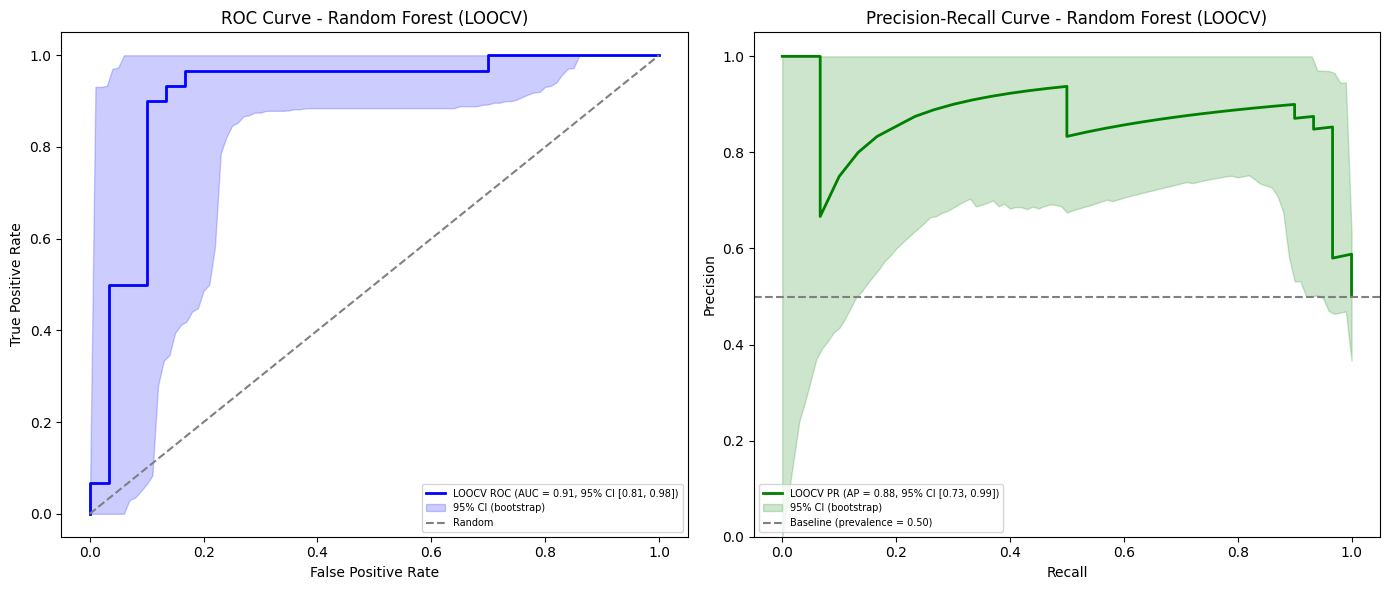

In [26]:

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, LeaveOneOut, StratifiedKFold, \
    GridSearchCV
from sklearn.metrics import accuracy_score, roc_curve, auc, precision_recall_curve, \
    average_precision_score
import matplotlib.pyplot as plt
import numpy as np

# Handle NaN mask
nan_mask = ~np.isnan(y_numeric)
X_clean = X[nan_mask]
y_clean = y_numeric[nan_mask]

# Hyperparameter optimization with GridSearchCV
param_grid = {
    'n_estimators': [100, 200, 500],
    'max_depth': [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2'],
}

inner_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=inner_cv,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1,
)
grid_search.fit(X_clean, y_clean)
best_params = grid_search.best_params_
print(f"Best hyperparameters: {best_params}")
print(f"Best CV ROC-AUC: {grid_search.best_score_:.4f}")

# Initialize Random Forest Classifier with best params
rf = RandomForestClassifier(random_state=42, **best_params)

# LOOCV
loo = LeaveOneOut()
rf_scores = cross_val_score(rf, X_clean, y_clean, cv=loo, scoring='accuracy')

print(f"LOOCV Accuracy: {rf_scores.mean():.2f} ± {rf_scores.std():.2f}")

# Fit on full data for feature importances
rf.fit(X_clean, y_clean)
feature_importances = rf.feature_importances_
top_features = np.argsort(feature_importances)[::-1][:20]

print(f"\nTop 20 most important features (indices): {top_features}")
print(f"Their importances: {feature_importances[top_features].round(4)}")

# ROC Curve using LOOCV
y_true_all = []
y_prob_all = []

for train_idx, test_idx in loo.split(X_clean):
    rf_fold = RandomForestClassifier(random_state=42, **best_params)
    rf_fold.fit(X_clean[train_idx], y_clean[train_idx])
    y_prob = rf_fold.predict_proba(X_clean[test_idx])[:, 1]
    y_true_all.extend(y_clean[test_idx])
    y_prob_all.extend(y_prob)

y_true_all = np.array(y_true_all)
y_prob_all = np.array(y_prob_all)

# Correlation between predicted response (probabilities) and ground truth y_clean
pearson_r, pearson_p = stats.pearsonr(y_true_all, y_prob_all)
spearman_r, spearman_p = stats.spearmanr(y_true_all, y_prob_all)
pointbiserial_r, pointbiserial_p = stats.pointbiserialr(y_true_all, y_prob_all)
print(f"\nCorrelation between predicted response and ground truth y_clean:")
print(f"  Pearson r        = {pearson_r:.4f} (p = {pearson_p:.4g})")
print(f"  Spearman r       = {spearman_r:.4f} (p = {spearman_p:.4g})")
print(f"  Point-biserial r = {pointbiserial_r:.4f} (p = {pointbiserial_p:.4g})")

fpr, tpr, _ = roc_curve(y_true_all, y_prob_all)
roc_auc = auc(fpr, tpr)

precision, recall, _ = precision_recall_curve(y_true_all, y_prob_all)
avg_precision = average_precision_score(y_true_all, y_prob_all)

# Bootstrap confidence interval for ROC and PR curves
n_bootstrap = 1000
rng = np.random.default_rng(42)
mean_fpr = np.linspace(0, 1, 101)
mean_recall = np.linspace(0, 1, 101)
boot_tprs = []
boot_aucs = []
boot_precisions = []
boot_aps = []

n_pred = len(y_true_all)
for _ in range(n_bootstrap):
    idx = rng.integers(0, n_pred, size=n_pred)
    if len(np.unique(y_true_all[idx])) < 2:
        continue
    fpr_b, tpr_b, _ = roc_curve(y_true_all[idx], y_prob_all[idx])
    interp_tpr_b = np.interp(mean_fpr, fpr_b, tpr_b)
    interp_tpr_b[0] = 0.0
    boot_tprs.append(interp_tpr_b)
    boot_aucs.append(auc(fpr_b, tpr_b))

    precision_b, recall_b, _ = precision_recall_curve(y_true_all[idx], y_prob_all[idx])
    # precision_recall_curve returns recall in decreasing order; reverse for interpolation
    interp_prec_b = np.interp(mean_recall, recall_b[::-1], precision_b[::-1])
    boot_precisions.append(interp_prec_b)
    boot_aps.append(average_precision_score(y_true_all[idx], y_prob_all[idx]))

boot_tprs = np.array(boot_tprs)
tpr_lower = np.percentile(boot_tprs, 2.5, axis=0)
tpr_upper = np.percentile(boot_tprs, 97.5, axis=0)
auc_lower = np.percentile(boot_aucs, 2.5)
auc_upper = np.percentile(boot_aucs, 97.5)

boot_precisions = np.array(boot_precisions)
prec_lower = np.percentile(boot_precisions, 2.5, axis=0)
prec_upper = np.percentile(boot_precisions, 97.5, axis=0)
ap_lower = np.percentile(boot_aps, 2.5)
ap_upper = np.percentile(boot_aps, 97.5)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

ax = axes[0]
ax.plot(fpr, tpr, color='blue', lw=2,
        label=f'LOOCV ROC (AUC = {roc_auc:.2f}, 95% CI [{auc_lower:.2f}, {auc_upper:.2f}])')
ax.fill_between(mean_fpr, tpr_lower, tpr_upper, color='blue', alpha=0.2,
                label='95% CI (bootstrap)')
ax.plot([0, 1], [0, 1], linestyle='--', color='grey', label='Random')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve - Random Forest (LOOCV)')
ax.legend(loc='lower right', fontsize=7)

ax = axes[1]
baseline = y_true_all.mean()
ax.plot(recall, precision, color='green', lw=2,
        label=f'LOOCV PR (AP = {avg_precision:.2f}, 95% CI [{ap_lower:.2f}, {ap_upper:.2f}])')
ax.fill_between(mean_recall, prec_lower, prec_upper, color='green', alpha=0.2,
                label='95% CI (bootstrap)')
ax.axhline(baseline, linestyle='--', color='grey',
           label=f'Baseline (prevalence = {baseline:.2f})')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_ylim(0, 1.05)
ax.set_title('Precision-Recall Curve - Random Forest (LOOCV)')
ax.legend(loc='lower left', fontsize=7)

plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd
from sklearn.metrics import confusion_matrix

# Use predictions from the last fold's detailed reports, or aggregate across all folds via LOOCV-like CV
y_true_all_cv = []
y_pred_all_cv = []

for train_index, test_index in cv.split(scaled_log_fractions, y_numeric):
    X_train, X_test = scaled_log_fractions[train_index], scaled_log_fractions[
        test_index]
    y_train, y_test = y_numeric[train_index], y_numeric[test_index]
    decision_tree.fit(X_train, y_train)
    y_pred_fold = decision_tree.predict(X_test)
    y_true_all_cv.extend(y_test)
    y_pred_all_cv.extend(y_pred_fold)

y_true_all_cv = np.array(y_true_all_cv)
y_pred_all_cv = np.array(y_pred_all_cv)

inv_mapping = {0: 'NR', 1: 'R'}
y_true_labels = [inv_mapping[int(v)] for v in y_true_all_cv]
y_pred_labels = [inv_mapping[int(v)] for v in y_pred_all_cv]

conf_table = pd.crosstab(
    pd.Series(y_true_labels, name='Actual Response'),
    pd.Series(y_pred_labels, name='Predicted Response'),
    margins=True,
)
conf_table


In [ ]:
X.shape

In [ ]:
correlations

In [ ]:
import numpy as np
from scipy import stats

ns = [10, 20, 30, 40, 50, 60]
n_iter = 100
res = np.empty(shape=(len(ns), n_iter))

for j, n in enumerate(ns):#range(100):
    for k in range(n_iter):
        index = np.random.choice(range(gide.n_obs), size=n, replace=True)

        mapping = {'NR': 0, 'R': 1}
        y_numeric = gide.obs.response.map(mapping).values.astype(float)[index]
        X = np.log(fractions + 1e-6).astype(float)[index, :]

        correlations = []
        p_values = []

        for i in range(X.shape[1]):
            # Drop rows where y_numeric might be NaN (if mapping didn't cover all values)
            mask = ~np.isnan(y_numeric)

            r, p = stats.pointbiserialr(y_numeric[mask], X[mask, i])
            correlations.append(r)
            p_values.append(p)

        correlations = np.array(correlations)
        p_values = np.array(p_values)

        res[j, k] = (p_values < (0.05)).sum()
        # print((p_values < (0.05)).sum(), (p_values < (0.05/p_values.shape[0])).sum())

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

neg_log_p = -np.log10(p_values + 1e-14)

plt.figure(figsize=(8, 6))
plt.scatter(correlations, neg_log_p, alpha=0.6, color='grey')
sig_mask = (p_values < 0.05)# & (np.abs(correlations) > 0.3)
plt.scatter(correlations[sig_mask], neg_log_p[sig_mask], color='red', label='Significant')

# 4. Add threshold lines
plt.axhline(-np.log10(0.05), color='black', linestyle='--', alpha=0.5) # p=0.05 line
plt.axvline(0, color='black', alpha=0.05)

plt.xlabel('Point-Biserial Correlation (R)')
plt.ylabel('-log10(p-value)')
plt.title('Cluster Association with Response')
plt.legend()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

n_top_red = 15
#n_next_green = 25
n_bottom_blue = 15

sorted_idx = np.argsort(-correlations)
sorted_corr = correlations[sorted_idx]

colors = np.array(['grey'] * len(sorted_corr), dtype=object)
colors[:n_top_red] = 'red'
#colors[n_top_red:n_top_red + n_next_green] = 'green'
colors[-n_bottom_blue:] = 'blue'

plt.figure(figsize=(4, 4))
plt.bar(np.arange(len(sorted_corr)), sorted_corr, color=colors, width=1.0)
plt.axhline(0, color='black', linewidth=0.5)
plt.xlabel('Feature (sorted by correlation)')
plt.ylabel('Point-Biserial Correlation')
plt.title('Point-Biserial Correlations Sorted (Most Positive to Most Negative)')
plt.tight_layout()
plt.savefig("/tmp/features.svg")
plt.show()



In [ ]:
sig_reference = reference[sig_mask, :].copy()

In [ ]:
from pyensembl import EnsemblRelease

ensembl = EnsemblRelease(111)
markers_name = {
    "Immune": ["PTPRC"],
    "Fibroblast": ["COL1A1", "COL1A2", "COL3A1"],
    "Inflammatory CAF": ["DPT", "CXCL12", "CFD", "IL6"],
    "Oxidative CAF": ["PDGFRA", "FN1"],
    "Matrix metalloproteinase CAF": ["TIMP1", "ADAM10"],
    "Transcriptional CAF": ["FN1", "COL1A2"],
    #"Mitochondrial CAF": ["SDHA", "MT-CO1", "NDUFB8"],
    #"Mycobacteria": ["TUBB", "FTH1"],
    "Matrix CAF": ["COL11A1", "MMP11", "CTHRC1", "FAP"],
    "Tumor": ["PMEL", "MLANA", "S100B", "SOX10"],
    'T-cell': ['CD3D', 'CD3E', 'CD3G', 'CD4', 'CD8A'],
    'B-cell': ['CD19', 'MS4A1'],
    'Myeloid': ['CD14', 'LYZ', 'ITGAM'],
    'NK': ['NCAM1', 'KLRB1'],
    "Pan-Myeloid": ["LYZ", "CD14", "AIF1", "FCER1G", "TYROBP"],
    "Monocytes (Classical)": ["S100A8", "S100A9", "VCAN", "FCN1"],
    "Monocytes (Non-classical)": ["FCGR3A", "MS4A7", "LST1"],
    "Macrophages (General)": ["CD68", "CD14", "CD163", "CSF1R", "ADGRE1"],
    "TAMs (M2-like)": ["MERTK", "C1QA", "APOE", "MS4A6A", "CXCL8", "TGFBI"],
    "TAMs (M1-like)": ["NOS2", "CD80", "CXCL10", "IDO1"],
    "cDC1 (Cross-presenting)": ["CLEC9A", "XCR1", "BATF3", "CADM1"],
    "cDC2 (Antigen-presenting)": ["CD1C", "FCER1A", "CLEC10A", "HLA-DQA1"],
    "pDC (Interferon)": ["CLEC4C", "LILRA4", "TCF4", "IRF7"],
    "mregDC (Migratory)": ["LAMP3", "CCR7", "CD40", "BIRC3"],
    "Neutrophils": ["S100A12", "FCGR3B", "CXCR1", "CXCR2", "NAMPT"],
    "Mast Cells": ["TPSAB1", "CPA3", "MS4A2", "KIT"],
    "MDSC-like": ["S100A11", "ARG1", "S100A12"],
    "Non-carcinoma": ["LAPTM5", "IL2RG"],
    # Broad Lineage
    "Pan-T": ["CD3D", "CD3E", "CD3G"],
    "CD4+ T": ["CD4", "IL7R"],
    "CD8+ T": ["CD8A", "CD8B"],

    # Differentiation States
    "Naïve / Early Memory": ["CCR7", "SELL", "LEF1", "TCF7"],
    "Effector / Cytotoxic": ["GZMB", "GZMK", "PRF1", "NKG7"],
    "Resident Memory (Trm)": ["ITGAE", "CD69", "CXCR6"],

    # Functional & Regulatory
    "Regulatory (Treg)": ["FOXP3", "IL2RA", "IKZF2", "CTLA4"],
    "Exhausted (Tex)": ["PDCD1", "LAG3", "HAVCR2", "TIGIT", "TOX"],
    "Proliferating": ["MKI67", "TOP2A", "PCNA"],

    # Other Lymphocytes (for exclusion/differentiation)
    "NK Cells": ["NCAM1", "KLRD1", "KLRB1", "GNLY"]
}
markers_id_dict = {celltype: [ensembl.genes_by_name(gene_name)[0].gene_id for gene_name in gene_list] for celltype, gene_list in markers_name.items()}
markers_id = {gene_name: ensembl.genes_by_name(gene_name)[0].gene_id for gene_list in markers_name.values() for gene_name in gene_list}

In [ ]:
import matplotlib.pyplot as plt
bdata = reference[reference.obs["leiden"].isin(["147", "418", "244", "173", "155", "80", "75", "418", "6"])]
sc.pp.log1p(bdata)
dotplot = sc.pl.dotplot(bdata, var_names=markers_id_dict, groupby='leiden', return_fig=False)
dotplot.get_axes()['mainplot_ax'].set_xticklabels(np.concat(list(markers_name.values())))
plt.show()

In [ ]:
pos_sig_mask = (p_values < 0.01) & (correlations > 0.0)
pos_sig_reference = reference[pos_sig_mask, :].copy()
sc.pp.log1p(pos_sig_reference)
dotplot = sc.pl.dotplot(pos_sig_reference, var_names=markers_id_dict, groupby='leiden', return_fig=True)
dotplot.get_axes()['mainplot_ax'].set_xticklabels(np.concat(list(markers_name.values())))
plt.show()

In [ ]:
neg_sig_mask = (p_values < 0.01) & (correlations < 0.0)
neg_sig_reference = reference[neg_sig_mask, :].copy()
sc.pp.log1p(neg_sig_reference)
dotplot = sc.pl.dotplot(neg_sig_reference, var_names=markers_id_dict, groupby='leiden', return_fig=True)
dotplot.get_axes()['mainplot_ax'].set_xticklabels(np.concat(list(markers_name.values())))
plt.show()

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

corr_matrix = np.corrcoef(fractions.T)
g = sns.clustermap(
    corr_matrix,
    cmap='RdBu_r',
    center=0,
    xticklabels=[],
    yticklabels=[],
    figsize=(15, 15),
    row_cluster=True,  # Enable clustering for rows
    col_cluster=True   # Enable clustering for columns
)

plt.show()

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

corr_matrix = np.corrcoef(fractions.T[sig_mask, :])
g = sns.clustermap(
    corr_matrix,
    cmap='RdBu_r',
    center=0,
    xticklabels=[],
    yticklabels=[],
    figsize=(15, 15),
    row_cluster=True,  # Enable clustering for rows
    col_cluster=True   # Enable clustering for columns
)
print(corr_matrix.shape)
plt.show()

In [ ]:
log_fractions.T[sig_mask, :].shape


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Assuming corr_matrix is already defined in your environment
# Let's perform PCA
pca = PCA(n_components=10)  # Reduce to 2 dimensions for visualization purposes
principal_components = pca.fit_transform(log_fractions[:, sig_mask])

In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

X_train, X_test, y_train, y_test = train_test_split(principal_components, y_numeric, test_size=0.2, random_state=42)
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train, y_train)
y_pred = log_reg.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

print(f"Accuracy: {accuracy}")
print("Confusion Matrix:")
print(conf_matrix)
print("Classification Report:")
print(class_report)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaled_log_fractions = StandardScaler().fit_transform(log_fractions)

In [ ]:
import numpy as np
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Assuming scaled_log_fractions and y_numeric are already defined
# scaled_log_fractions: ndarray of shape (n_samples, n_features)
# y_numeric: ndarray of shape (n_samples,)

# Step 1: Initialize the Decision Tree Classifier
decision_tree = DecisionTreeClassifier(random_state=42)

# Step 2: Set up cross-validation
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# Step 3: Evaluate the model using cross-validation
scores = cross_val_score(decision_tree, scaled_log_fractions, y_numeric, cv=cv, scoring='accuracy')

# Calculate mean and standard deviation of accuracy scores
mean_accuracy = np.mean(scores)
std_accuracy = np.std(scores)

print(f"Mean Accuracy: {mean_accuracy:.2f} ± {std_accuracy:.2f}")

# Optionally, you can also get more detailed metrics by fitting the model on each fold manually
detailed_reports = []

for train_index, test_index in cv.split(scaled_log_fractions, y_numeric):
    X_train, X_test = scaled_log_fractions[train_index], scaled_log_fractions[test_index]
    y_train, y_test = y_numeric[train_index], y_numeric[test_index]

    # Fit the model
    decision_tree.fit(X_train, y_train)

    # Make predictions
    y_pred = decision_tree.predict(X_test)

    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    conf_matrix = confusion_matrix(y_test, y_pred)
    class_report = classification_report(y_test, y_pred)

    detailed_reports.append({
        'accuracy': accuracy,
        'confusion_matrix': conf_matrix,
        'classification_report': class_report
    })

# # Print detailed reports for each fold
# for i, report in enumerate(detailed_reports):
#     print(f"Fold {i+1}:")
#     print(f"Accuracy: {report['accuracy']:.2f}")
#     print("Confusion Matrix:")
#     print(report['confusion_matrix'])
#     print("Classification Report")

In [ ]:
detailed_reports